## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

## Helper Functions

In [2]:
def make_train_step_fn(model, loss_function, optimizer):
    """
    This is a higher order function that returns the function for one train step.
    This will be called inside the training loop.
    Returns loss for that step.
    """
    def perform_train_step_fn(X, y):
        # Set the model to train mode
        model.train()
        # Do one iteration
        y_hat = model(X)
        
        # Calculate loss with the selected loss function
        loss = loss_function(y_hat, y)
        # Calculate gradients
        loss.backward()
        
        # Update parameters
        optimizer.step()
        # Set gradiants to zero
        optimizer.zero_grad()
        
        # Return loss for this iteration
        return loss.item()
    
    return perform_train_step_fn

## Data Preparation

In [3]:
%run -i data_generation/simple_linear_regression.py

In [4]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


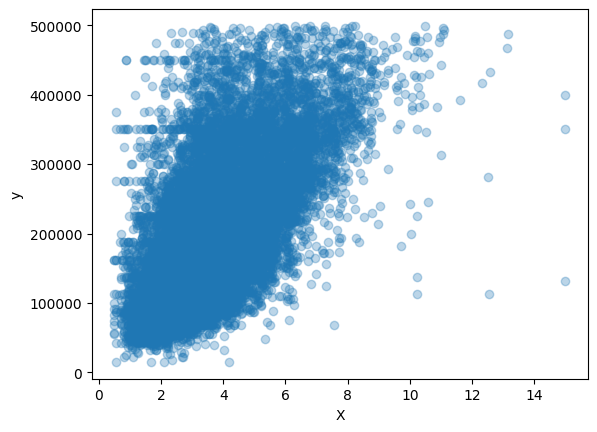

In [5]:
plt.scatter(X, y, alpha=0.3)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [10]:
%run -i data_prepration/v1.py

In [11]:
X_train_tensor.shape, y_train_tensor.shape

(torch.Size([15718, 1]), torch.Size([15718, 1]))

In [12]:
inputs, labels = next(iter(train_loader))

In [15]:
len(inputs), len(labels)

(128, 128)

## Model

In [16]:
# This returns train_step_function with model, optimizer and loss_function
%run -i model_configuration/v1.py

In [17]:
train_step_function

<function __main__.make_train_step_fn.<locals>.perform_train_step_fn(X, y)>

## Training

In [18]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
epochs = 1000

losses = []
for epoch in range(epochs):
    if epoch % 100 == 0:
        print(f'epoch {epoch}/{epochs}')
        
    batch_losses = []
    for x_batch, y_batch in train_loader:
        # send batch to device
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        batch_loss = train_step_function(x_batch, y_batch)
        batch_losses.append(batch_loss)
        
    loss = np.mean(batch_losses)
    losses.append(loss)

epoch 0/1000
epoch 100/1000
epoch 200/1000
epoch 300/1000
epoch 400/1000
epoch 500/1000
epoch 600/1000
epoch 700/1000
epoch 800/1000
epoch 900/1000


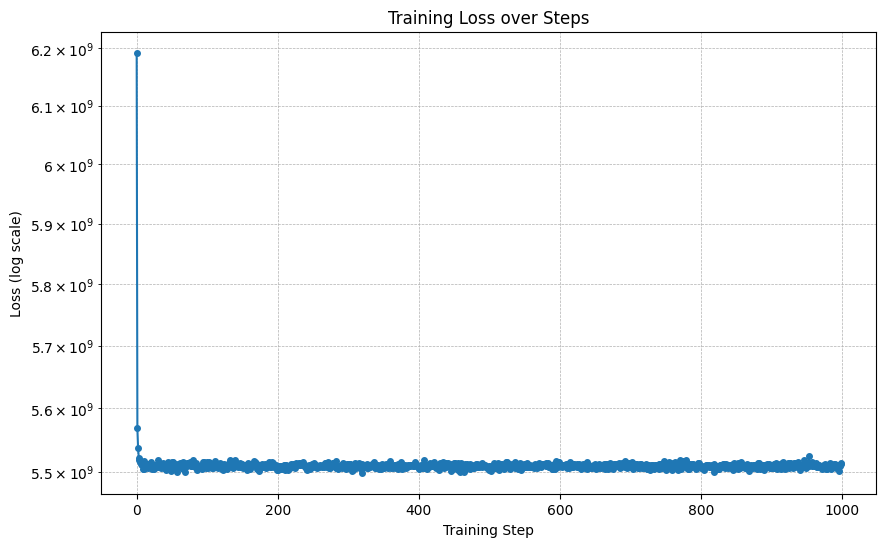

In [19]:
plt.figure(figsize=(10,6))
plt.plot(losses, marker='o', markersize=4)
plt.yscale('log')
plt.xlabel('Training Step')
plt.ylabel('Loss (log scale)')
plt.title('Training Loss over Steps')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

In [20]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[41314.6914]], device='cuda:0')), ('0.bias', tensor([45225.0117], device='cuda:0'))])


## Evaluation

In [21]:
X_val_tensor = torch.as_tensor(X_val).float().to(device)
model.eval()

with torch.no_grad():
    y_hat = model(X_val_tensor)

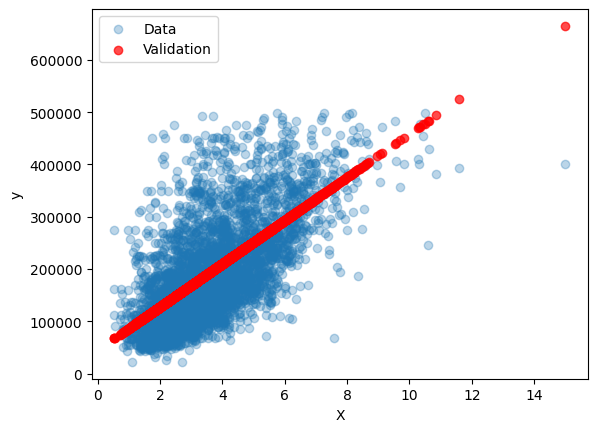

In [22]:
y_hat_pdf = pd.DataFrame(y_hat.cpu().detach().numpy())

plt.scatter(X_val, y_val, alpha=0.3, label="Data")
plt.scatter(X_val, y_hat_pdf, alpha=0.7, color="red", label="Validation")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()